# Choosing the Training Objective: Residual vs. Weighted-Residual vs. Data-Driven Losses

*The same steady-state Fourier Neural Operator is trained three times under three different losses. This experiment decides which objective we adopt for the rest of the study.*

---

## 1. The question

A neural operator can be taught in fundamentally different ways. We compare three objectives on the **steady-state** nonlinear conduction problem

$$\frac{d}{dx}\left(k(x,T)\,\frac{dT}{dx}\right)=0,\qquad k(x,T)=k_0(x)\bigl(1+\beta T^2\bigr),\quad \beta=1,$$

with fixed ends $T(0)=1,\ T(1)=0$. The conductivity $k_0(x)$ is a random field, and a Newton-Raphson finite-element solver supplies reference solutions.

## 2. The three losses

Given the network prediction $\hat T(x)$ and the discrete finite-element residual $r(\hat T)$ on the interior nodes:

- **MSE residual** — least-squares on the residual: $\ \mathcal{L}=\langle \lVert r \rVert^2\rangle$. Label-free.
- **Weighted residual (FOL)** — the Galerkin form, in which the predicted field itself is the test function and the residual is detached: $\ \mathcal{L}=\langle \hat T^{\text{int}}\!\cdot r\rangle$. Label-free.
- **Data-driven** — supervised regression against the FEM solution: $\ \mathcal{L}=\langle \lVert \hat T - T^{\text{FEM}}\rVert^2\rangle$. Requires labels.

<div align="center">

<br><em style="color:#475569;font-size:0.9em">Figure 1. The identical FNO is trained three times, changing only the objective. The weighted-residual (Galerkin) loss is label-free and is the one carried forward.</em>
</div>

## 3. Fair setup

All three runs use the **same** network (4 spectral layers, width 64, 16 modes), the **same** 400 training profiles, and the **same** AdamW schedule and epoch budget. Only the objective changes, so any difference in accuracy is attributable to the loss alone.

## 4. What the results show, and our choice

The plots below report accuracy on unseen in-distribution profiles, on out-of-distribution profiles at higher resolutions (a super-resolution test), and as error distributions. They motivate the decision that anchors the next chapters: **we adopt the weighted-residual (FOL) loss**, because it trains *without any labelled solutions* yet stays closest to the FEM reference and generalizes best out of distribution. This label-free objective is the one we reuse when we move to the architecture comparison and to the transient problem.

## 5. Train one FNO per loss

The cell below trains the three variants and prints each one's final relative $L^2$ error against FEM.

In [3]:
# ============================================================================
#  TRAINING CELL  --  run this FIRST.   (fast, optax + compiled epoch scan)
#  Trains one FNO per loss:  Residual (MSE) | Weighted residual | Data-driven
#  After it runs, `trained`, `histories`, `data_tr`, `data_val` are in memory.
# ============================================================================
import time
import jax
import jax.numpy as jnp
import optax

# ------------------------------- config -------------------------------------
N_NODES = 64
N_ELEM  = N_NODES - 1
GRID    = jnp.linspace(0.0, 1.0, N_NODES)
DX      = 1.0 / (N_NODES - 1)

K_MIN, K_MAX = 1.0, 10.0
BETA    = 1.0

FNO_LAYERS, FNO_MODES, FNO_HIDDEN = 4, 16, 64

N_TRAIN, N_VAL = 400, 64
EPOCHS, BATCH, LR = 250, 32, 3e-3
STEPS_PER_EPOCH  = max(1, N_TRAIN // BATCH)      # compiled steps inside one epoch
SEED = 0
XI = 0.57735026919                               # 2-pt Gauss point
for nm in ["GRID", "trained", "data_tr", "data_val", "predict_fno", "fem_solver",
           "N_NODES", "K_MIN", "K_MAX"]:
    print(f"{nm:12s}: {'OK' if nm in dir() else 'MISSING'}")

# ------------------------------- FEM solver ---------------------------------
@jax.jit
def fem_solver(phi_profile, beta):
    n = phi_profile.shape[0]
    dx = 1.0 / (n - 1)
    def nr_step(T, _):
        K_mat, R_vec = jnp.zeros((n, n)), jnp.zeros(n)
        for e in range(n - 1):
            ix = jnp.array([e, e + 1])
            for s in (-1, 1):
                N = jnp.array([0.5 * (1 - s * XI), 0.5 * (1 + s * XI)])
                B = jnp.array([-0.5, 0.5]) / (dx / 2.0)
                p_gp = jnp.dot(N, phi_profile[ix]); T_gp = jnp.dot(N, T[ix])
                k  = p_gp * (1.0 + beta * (T_gp ** 2))
                dk = p_gp * beta * 2.0 * T_gp
                R_vec = R_vec.at[ix].add((B * k * jnp.dot(B, T[ix])) * (dx / 2.0))
                K_mat = K_mat.at[jnp.ix_(ix, ix)].add(
                    (jnp.outer(B, B) * k +
                     jnp.outer(B, N) * dk * jnp.dot(B, T[ix])) * (dx / 2.0))
        free = jnp.arange(1, n - 1)
        dT = jnp.linalg.solve(K_mat[jnp.ix_(free, free)], -R_vec[free])
        return T.at[free].add(dT), None
    final_T, _ = jax.lax.scan(nr_step, jnp.linspace(1.0, 0.0, n), None, length=20)
    return final_T


# ------------------- discrete weak residual (Galerkin) ----------------------
def weak_residual(T, phi_nodes, beta):
    Tl, Tr = T[:-1], T[1:]
    pl, pr = phi_nodes[:-1], phi_nodes[1:]
    grad = (Tr - Tl) / DX
    Tg1 = 0.5 * (1 + XI) * Tl + 0.5 * (1 - XI) * Tr
    Tg2 = 0.5 * (1 - XI) * Tl + 0.5 * (1 + XI) * Tr
    pg1 = 0.5 * (1 + XI) * pl + 0.5 * (1 - XI) * pr
    pg2 = 0.5 * (1 - XI) * pl + 0.5 * (1 + XI) * pr
    k1 = pg1 * (1.0 + beta * Tg1 ** 2)
    k2 = pg2 * (1.0 + beta * Tg2 ** 2)
    flux = 0.5 * grad * (k1 + k2)
    R = jnp.zeros(T.shape[0])
    R = R.at[:-1].add(-flux)
    R = R.at[1:].add(flux)
    return R


# ------------------------------- FNO ----------------------------------------
def init_fno(key):
    keys = jax.random.split(key, FNO_LAYERS * 3 + 2)
    params, in_ch, ki = [], 2, 0
    for _ in range(FNO_LAYERS):
        out_ch = FNO_HIDDEN
        scale = 1.0 / (in_ch * out_ch)
        w_fft_r = jax.random.normal(keys[ki], (FNO_MODES, in_ch, out_ch)) * scale; ki += 1
        w_fft_i = jax.random.normal(keys[ki], (FNO_MODES, in_ch, out_ch)) * scale; ki += 1
        w_loc   = jax.random.normal(keys[ki], (in_ch, out_ch)) * jnp.sqrt(2.0 / in_ch); ki += 1
        params.append({'w_fft_r': w_fft_r, 'w_fft_i': w_fft_i,
                       'w_loc': w_loc, 'b_loc': jnp.zeros(out_ch)})
        in_ch = out_ch
    params.append({'w_out': jax.random.normal(keys[ki], (FNO_HIDDEN, 1)) * 0.01,
                   'b_out': jnp.zeros(1)}); ki += 1
    params.append({'w_skip': jax.random.normal(keys[ki], (2, 1)) * 0.01})
    return params


def predict_fno(params, k_elem, grid_1d):
    grid_col = grid_1d.reshape(-1, 1)
    k_nodes = jnp.concatenate([k_elem[:1], 0.5 * (k_elem[:-1] + k_elem[1:]), k_elem[-1:]])
    if k_nodes.shape[0] != grid_col.shape[0]:
        k_nodes = jnp.interp(grid_1d, jnp.linspace(0, 1, k_nodes.shape[0]), k_nodes)
    h = h_in = jnp.concatenate([grid_col, k_nodes.reshape(-1, 1)], axis=1)
    for i in range(FNO_LAYERS):
        p = params[i]
        x_fft = jnp.fft.rfft(h, axis=0)
        modes = min(FNO_MODES, x_fft.shape[0])
        w_cpx = p['w_fft_r'][:modes] + 1j * p['w_fft_i'][:modes]
        x_fft_out = jnp.einsum('mi,mio->mo', x_fft[:modes], w_cpx)
        padded = jnp.zeros((x_fft.shape[0], FNO_HIDDEN),
                           dtype=x_fft_out.dtype).at[:modes].set(x_fft_out)
        h = jax.nn.gelu(jnp.fft.irfft(padded, n=h.shape[0], axis=0)
                        + jnp.dot(h, p['w_loc']) + p['b_loc'])
    T_nn = jnp.dot(h, params[-2]['w_out']) + params[-2]['b_out'] \
        + jnp.dot(h_in, params[-1]['w_skip'])
    return ((1.0 - grid_col) + (grid_col * (1.0 - grid_col) * T_nn)).squeeze(-1)


def _sample_T(params, k_elem):
    return predict_fno(params, k_elem, GRID)


# ---------------------------- THE THREE LOSSES ------------------------------
def l_residual(params, phi, k_elem, T_fem):          # MSE of weak residual
    R = weak_residual(_sample_T(params, k_elem), phi, BETA)
    return jnp.mean(R[1:-1] ** 2)

def l_weighted(params, phi, k_elem, T_fem):          # weighted residual (FOL)
    T = _sample_T(params, k_elem)
    R = jax.lax.stop_gradient(weak_residual(T, phi, BETA))
    return jnp.sum(T[1:-1] * R[1:-1])

def l_supervised(params, phi, k_elem, T_fem):        # data-driven
    return jnp.mean((_sample_T(params, k_elem) - T_fem) ** 2)

LOSSES = {"Residual": l_residual, "WeightedRes": l_weighted, "Supervised": l_supervised}


def make_batch_loss(per_sample):
    def batch_loss(params, PHI, KEL, TFEM):
        return jnp.mean(jax.vmap(per_sample, in_axes=(None, 0, 0, 0))(params, PHI, KEL, TFEM))
    return batch_loss

def rel_l2(params, PHI, KEL, TFEM):
    preds = jax.vmap(_sample_T, in_axes=(None, 0))(params, KEL)
    return jnp.mean(jnp.linalg.norm(preds - TFEM, axis=1)
                    / (jnp.linalg.norm(TFEM, axis=1) + 1e-8))


# ------------------------------- data ---------------------------------------
def random_k(key, n):
    k1, k2 = jax.random.split(key)
    freqs = jnp.arange(1, 9)
    amps = jax.random.normal(k1, (8,)) / (freqs ** 1.1)
    phases = jax.random.uniform(k2, (8,), minval=0, maxval=2 * jnp.pi)
    raw = jnp.sum(amps[:, None] * jnp.sin(freqs[:, None] * jnp.pi *
                  jnp.linspace(0, 1, n) + phases[:, None]), axis=0)
    return K_MIN + (K_MAX - K_MIN) * ((raw - raw.min()) / (raw.max() - raw.min() + 1e-8))

def build_dataset(key, m):
    keys = jax.random.split(key, m)
    PHI = jax.vmap(lambda k: random_k(k, N_NODES))(keys)
    KEL = 0.5 * (PHI[:, :-1] + PHI[:, 1:])
    TFEM = jax.vmap(fem_solver, in_axes=(0, None))(PHI, BETA)
    return PHI, KEL, TFEM


# ------------------------------- train (fast) -------------------------------
def make_optimizer():
    sched = optax.cosine_decay_schedule(LR, EPOCHS * STEPS_PER_EPOCH, alpha=0.01)
    return optax.chain(optax.clip_by_global_norm(1.0),
                       optax.adamw(sched, weight_decay=1e-4))

def train(loss_name, data_tr, data_val, seed=SEED):
    PHI, KEL, TFEM = data_tr
    batch_loss = make_batch_loss(LOSSES[loss_name])
    opt = make_optimizer()
    m = PHI.shape[0]

    def one_step(carry, key):
        params, opt_state = carry
        idx = jax.random.randint(key, (BATCH,), 0, m)
        l, g = jax.value_and_grad(batch_loss)(params, PHI[idx], KEL[idx], TFEM[idx])
        updates, opt_state = opt.update(g, opt_state, params)
        params = optax.apply_updates(params, updates)
        return (params, opt_state), l

    @jax.jit
    def run_epoch(params, opt_state, key):
        keys = jax.random.split(key, STEPS_PER_EPOCH)
        (params, opt_state), losses = jax.lax.scan(one_step, (params, opt_state), keys)
        return params, opt_state, jnp.mean(losses)      # whole epoch runs compiled

    params = init_fno(jax.random.PRNGKey(seed + 1))
    opt_state = opt.init(params)
    key = jax.random.PRNGKey(seed + 7)
    hist = {"epoch": [], "train_loss": [], "val_l2": []}
    t0 = time.time()
    for ep in range(EPOCHS):
        key, sub = jax.random.split(key)
        params, opt_state, mean_loss = run_epoch(params, opt_state, sub)
        hist["epoch"].append(ep + 1)
        hist["train_loss"].append(float(mean_loss))            # 1 sync / epoch
        hist["val_l2"].append(float(rel_l2(params, *data_val)))  # 1 sync / epoch
    print(f"  [{loss_name:<11}] final val rel-L2 = {hist['val_l2'][-1]*100:6.3f}%"
          f"   ({time.time()-t0:5.1f}s)")
    return params, hist


# ------------------------------- RUN ----------------------------------------
key = jax.random.PRNGKey(SEED)
ktr, kval = jax.random.split(key)
data_tr  = build_dataset(ktr,  N_TRAIN)
data_val = build_dataset(kval, N_VAL)

print("Training one FNO per loss ...")
trained, histories = {}, {}
for name in LOSSES:
    trained[name], histories[name] = train(name, data_tr, data_val)
print("Done. `trained`, `histories`, `data_tr`, `data_val` ready for the plot cell.")

GRID        : OK
trained     : MISSING
data_tr     : MISSING
data_val    : MISSING
predict_fno : MISSING
fem_solver  : MISSING
N_NODES     : OK
K_MIN       : OK
K_MAX       : OK
Training one FNO per loss ...
  [Residual   ] final val rel-L2 =  0.708%   ( 35.0s)
  [WeightedRes] final val rel-L2 =  0.208%   ( 35.6s)
  [Supervised ] final val rel-L2 =  0.651%   ( 36.0s)
Done. `trained`, `histories`, `data_tr`, `data_val` ready for the plot cell.


## 6. Accuracy, generalization, and error distributions

In-distribution predictions, out-of-distribution (super-resolution) predictions, and box plots of the spatial error for the three losses across train / validation / OOD.

Built 50 OOD scenarios across [64, 96, 128, 160, 192, 256]


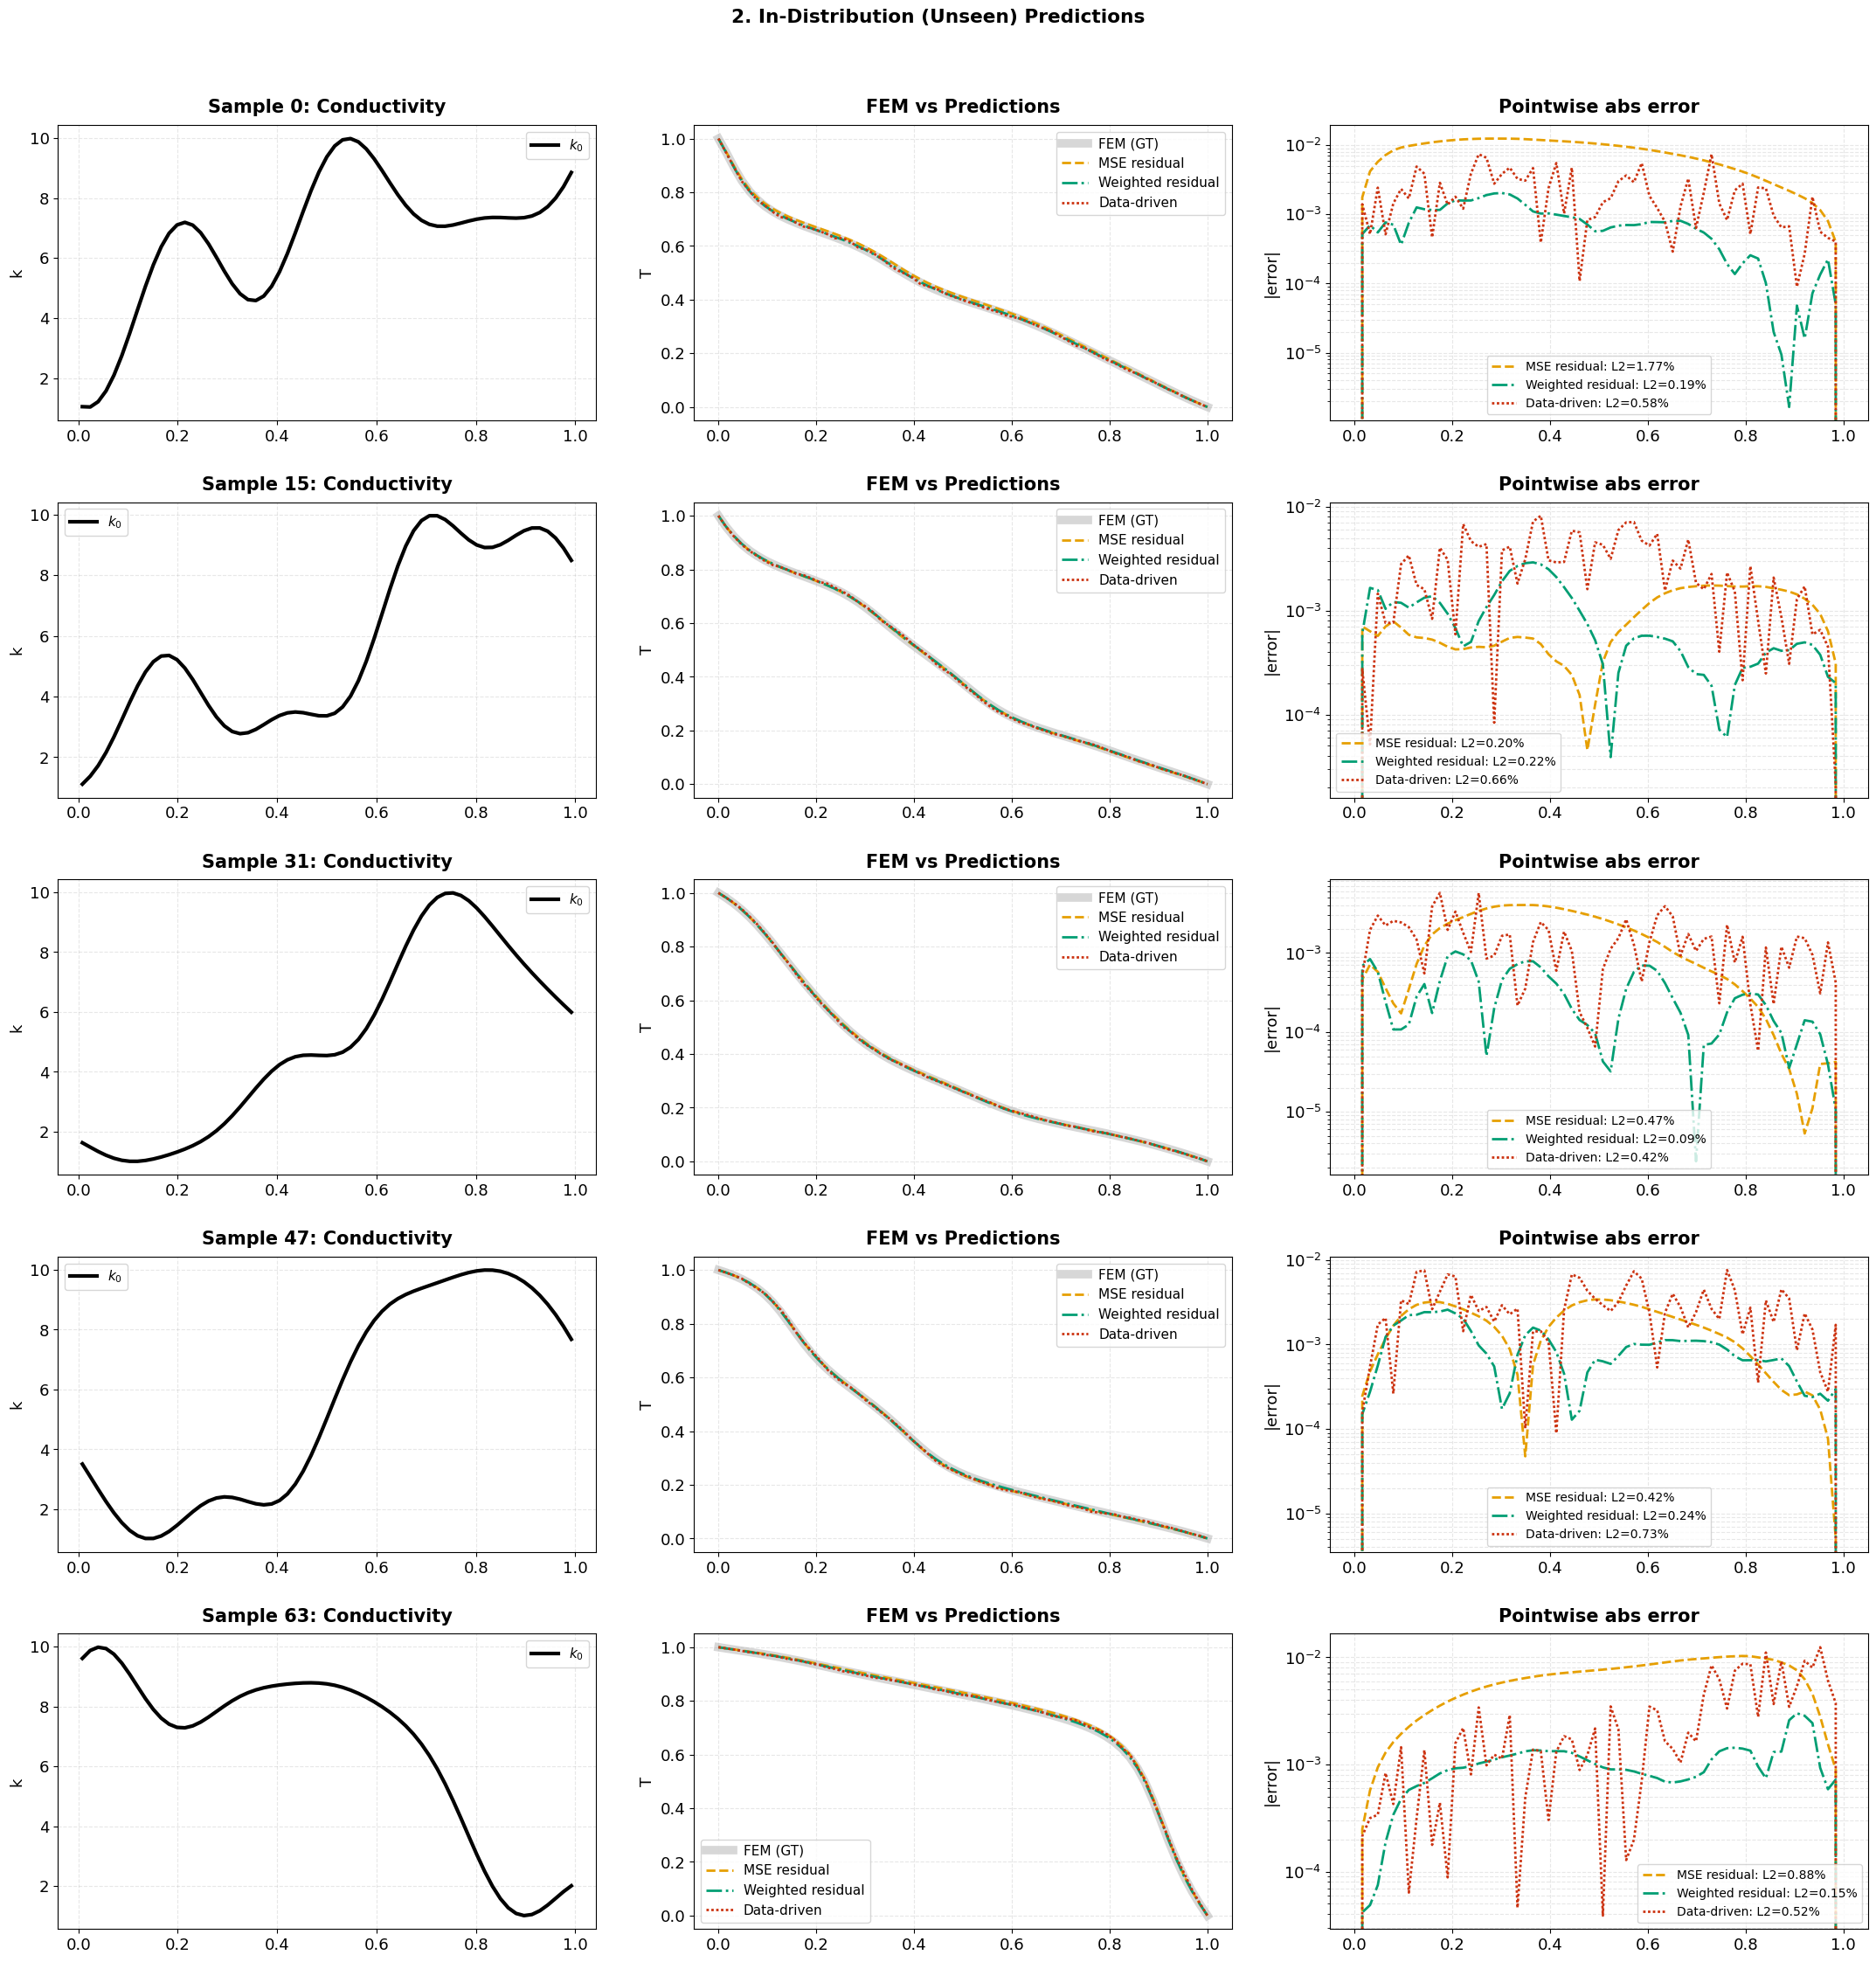

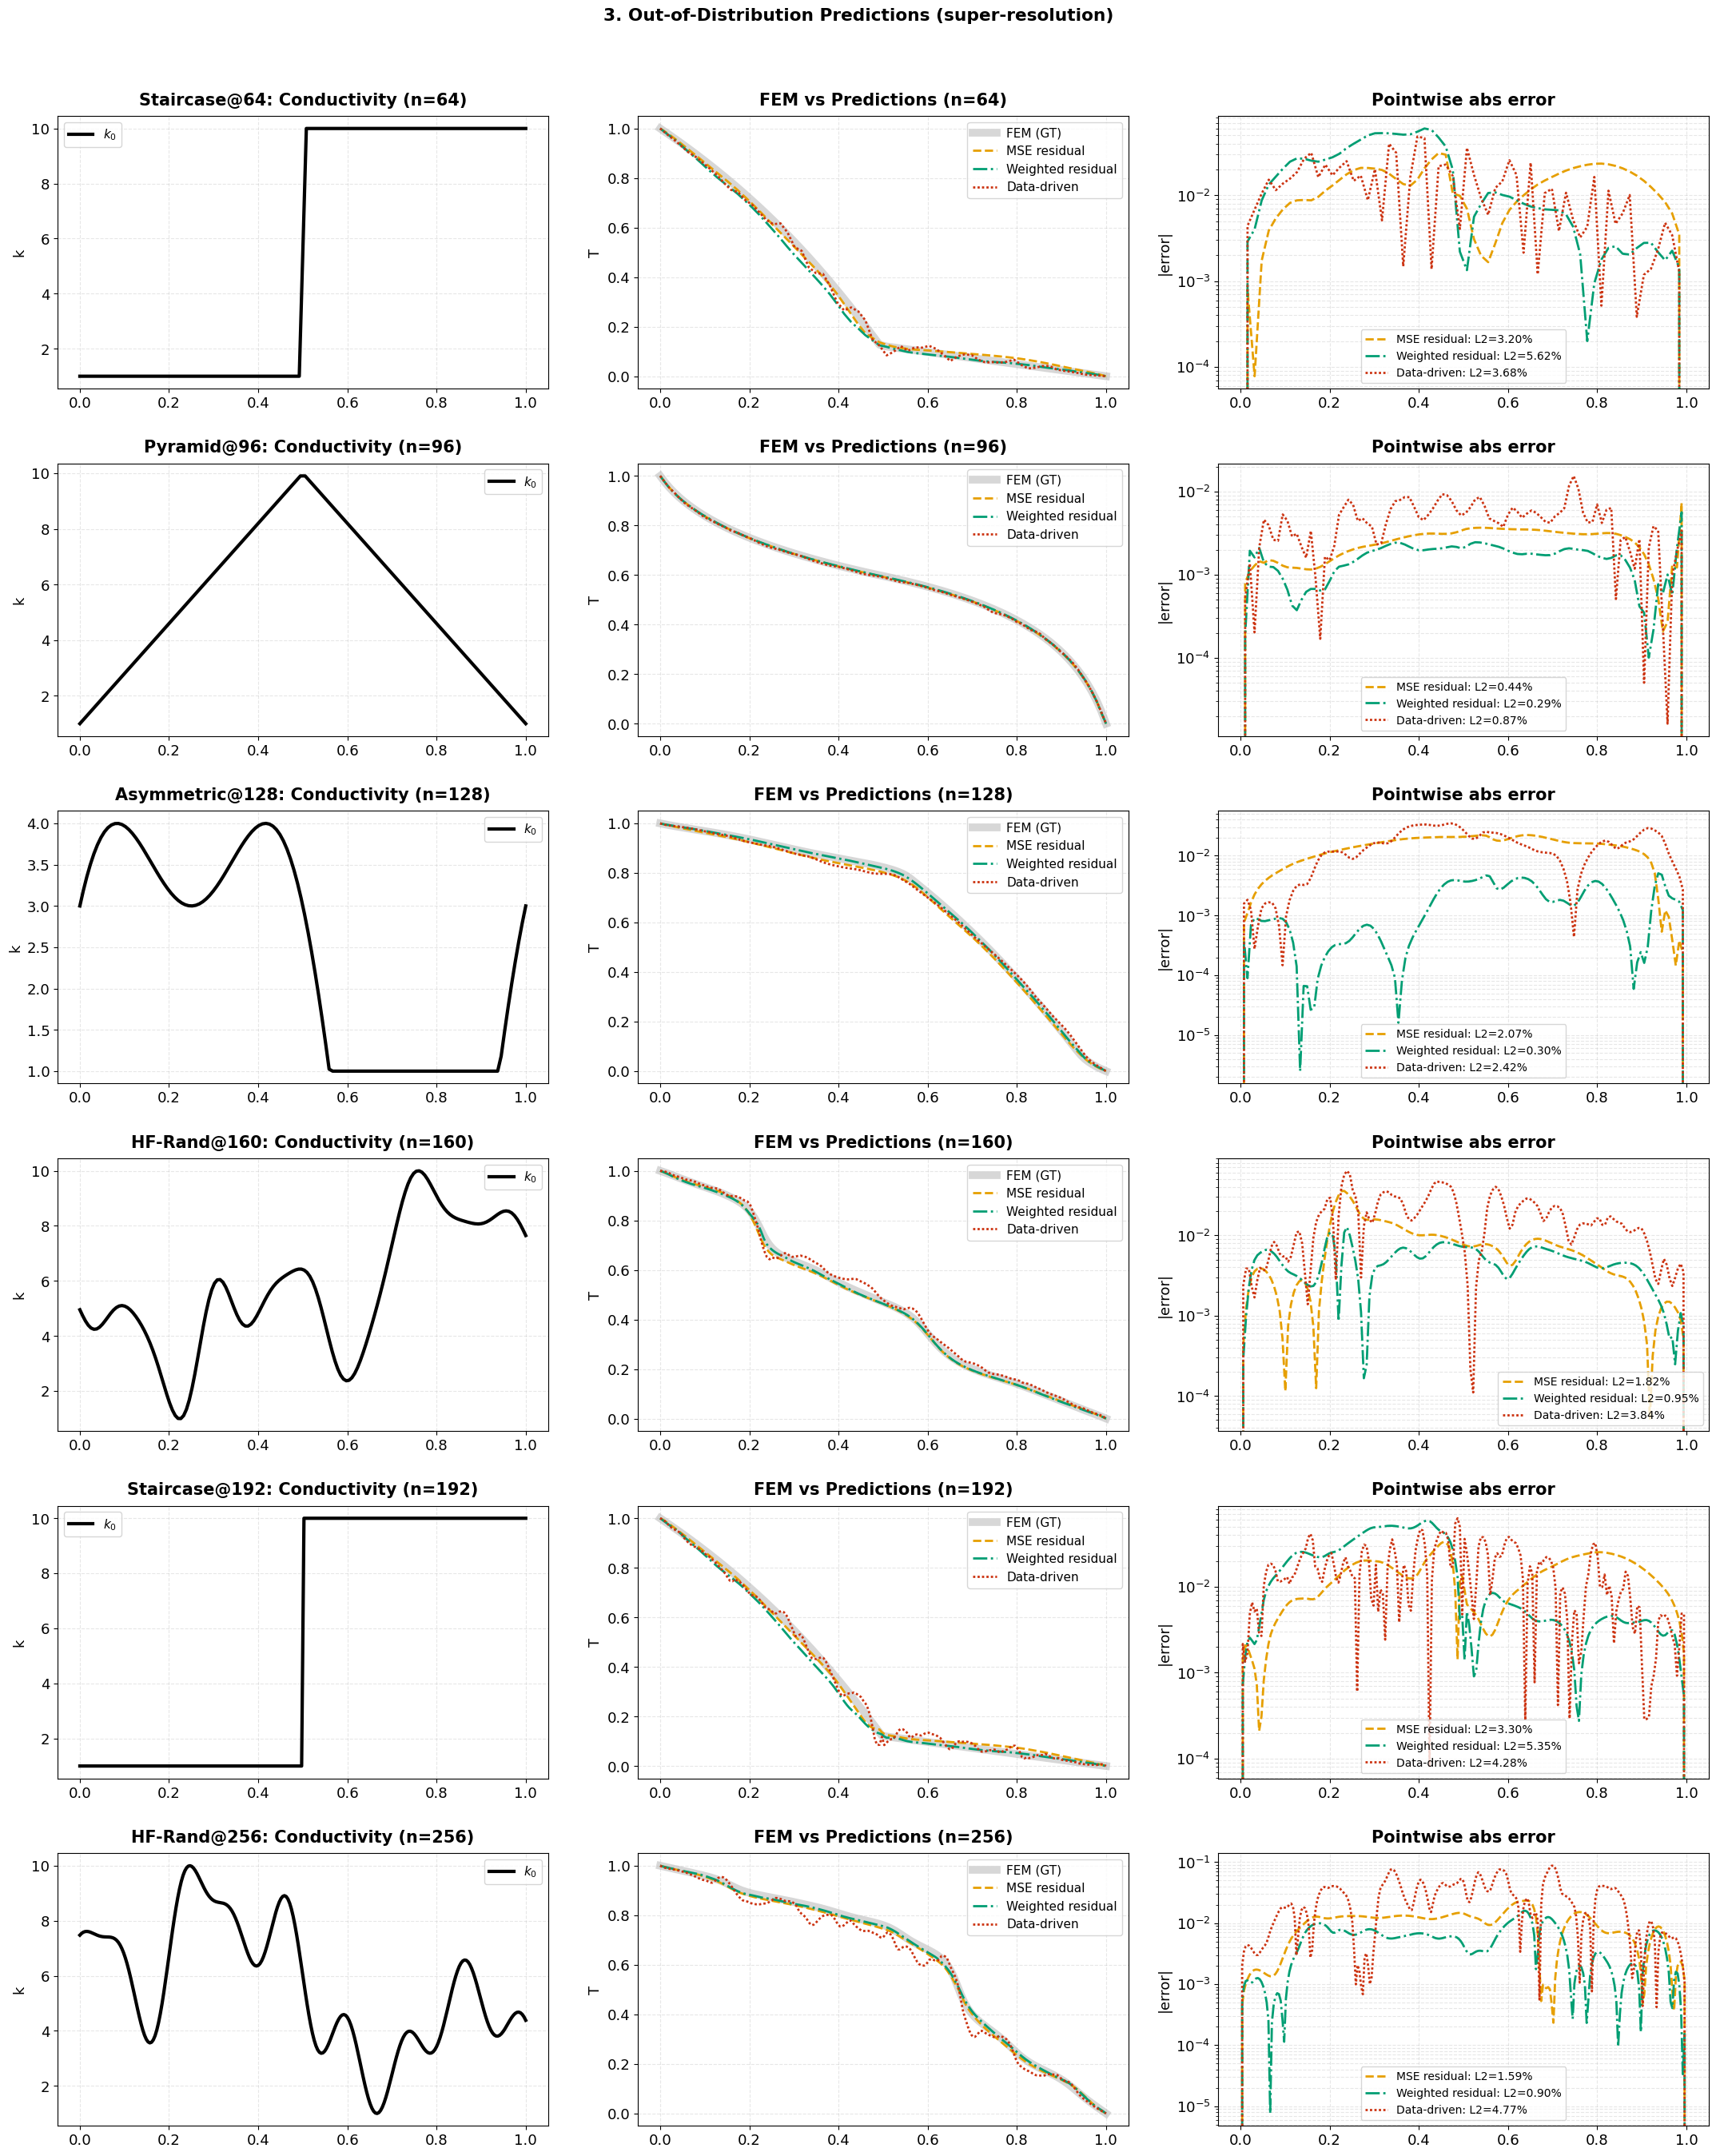

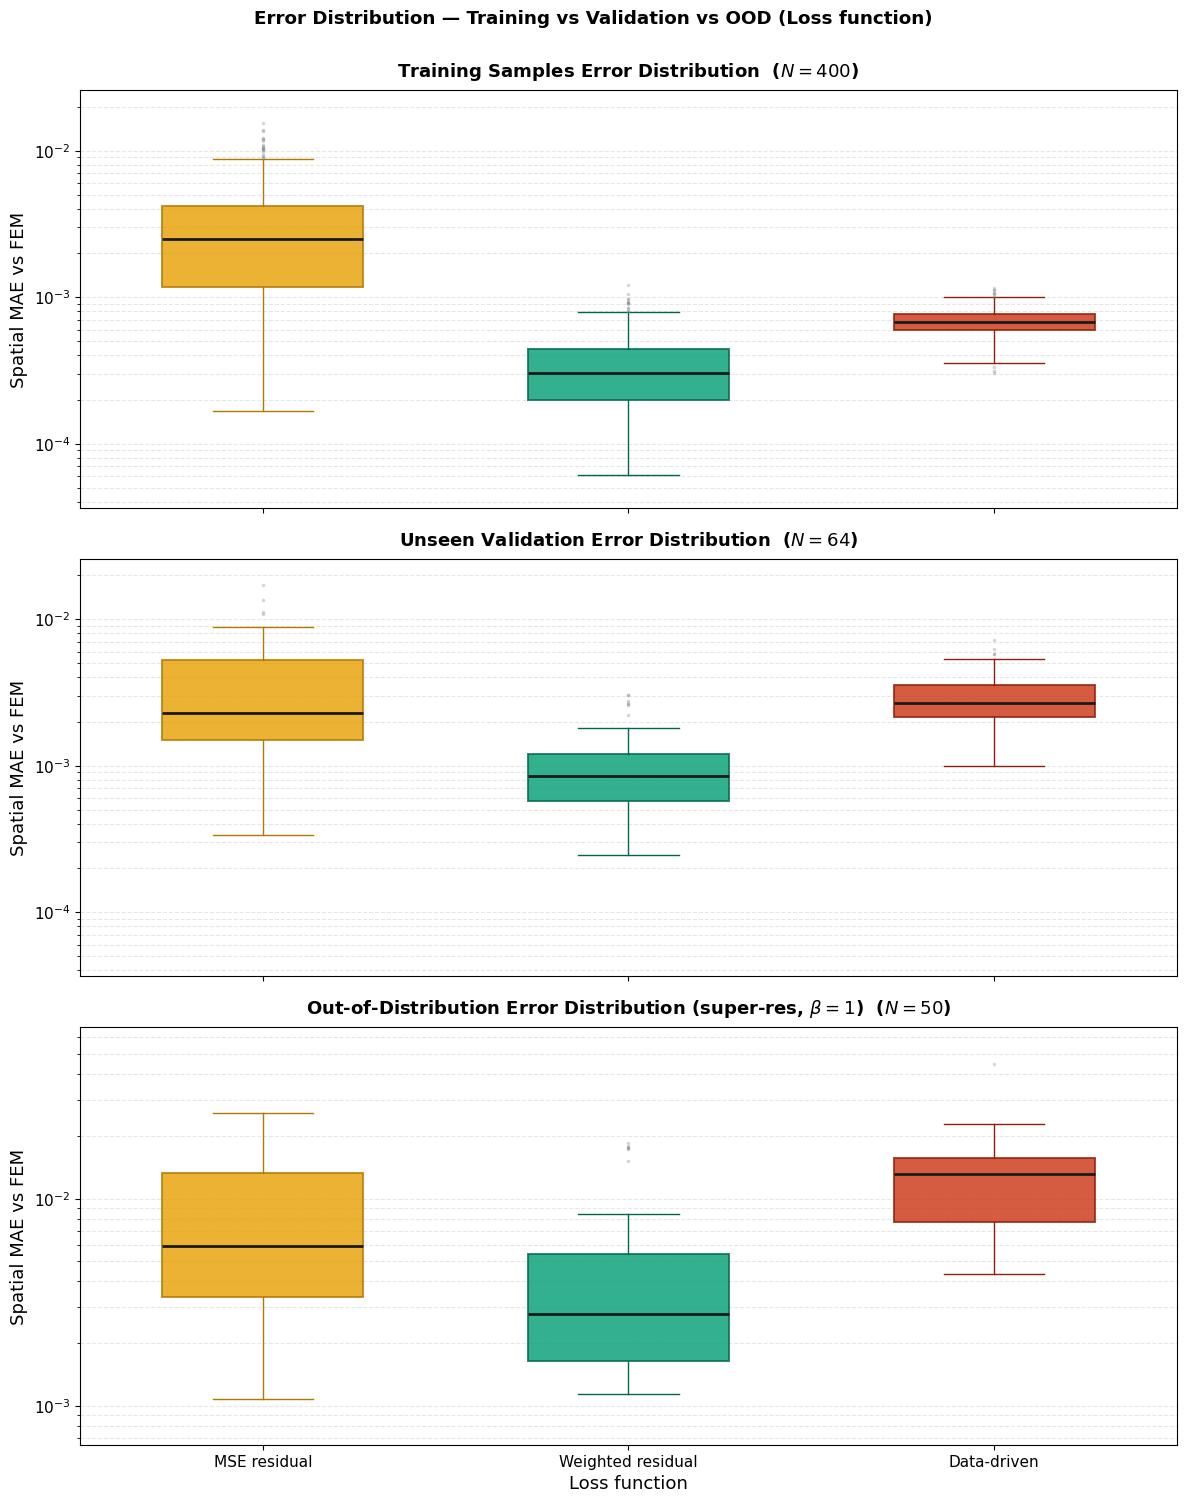

Saved: plot2_indist.png, plot3_ood.png, plot_loss_train_val_ood.png


In [4]:
# ==========================================================================
#  PLOTS  —  run AFTER the training cell (needs trained, data_tr, data_val)
#  (2) in-distribution predictions   (3) OOD predictions   (4) box plots
# ==========================================================================
import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp

LOSS_KEYS = ["Residual", "WeightedRes", "Supervised"]
COLORS = {"Residual": "#E69F00", "WeightedRes": "#009E73", "Supervised": "#CC3311"}
EDGE   = {"Residual": "#B47800", "WeightedRes": "#00674D", "Supervised": "#8E1F0B"}
STYLES = {"Residual": "--", "WeightedRes": "-.", "Supervised": (0, (1, 1))}
LABEL  = {"Residual": "MSE residual", "WeightedRes": "Weighted residual",
          "Supervised": "Data-driven"}

x_elem_1d = 0.5 * (GRID[:-1] + GRID[1:])

def predict(name, k_elem, grid_1d):
    return np.asarray(predict_fno(trained[name], k_elem, grid_1d)).flatten()

def rl2(y_true, y_pred):                       # array-vs-array (distinct from training rel_l2)
    yt, yp = np.asarray(y_true).flatten(), np.asarray(y_pred).flatten()
    return float(np.linalg.norm(yt - yp) / (np.linalg.norm(yt) + 1e-8))

# ---- OOD scenario builders (super-res, beta=1) ----
def get_staircase(n): return jnp.where(jnp.linspace(0, 1, n) < 0.5, K_MIN, K_MAX)
def get_pyramid(n):   return K_MIN + (K_MAX - K_MIN) * (1.0 - jnp.abs(2*jnp.linspace(0,1,n)-1))
def get_asym(n):      return jnp.clip(K_MIN + 4*jnp.sin(2*jnp.pi*jnp.linspace(0,1,n))
                                       + 2*jnp.cos(4*jnp.pi*jnp.linspace(0,1,n)), K_MIN, K_MAX)
def get_random_k(key, n, max_freq=18, decay=0.8):
    freqs = jnp.arange(1, max_freq+1); k1, k2 = jax.random.split(key)
    amps = jax.random.normal(k1, (max_freq,)) / (freqs**decay)
    phases = jax.random.uniform(k2, (max_freq,), minval=0, maxval=2*jnp.pi)
    xs = jnp.linspace(0, 1, n)
    raw = jnp.sum(amps[:,None]*jnp.sin(freqs[:,None]*jnp.pi*xs+phases[:,None]), axis=0)
    return K_MIN + (K_MAX-K_MIN)*((raw-raw.min())/(raw.max()-raw.min()+1e-8))

OOD_RES_CHOICES = [N_NODES, 96, 128, 160, 192, 256]
N_OOD = 50

def build_ood(n_total, seed=101):
    scen, key = [], jax.random.PRNGKey(seed)
    fams = [("Staircase", get_staircase), ("Pyramid", get_pyramid), ("Asymmetric", get_asym)]
    for res in OOD_RES_CHOICES:
        for fname, fn in fams:
            scen.append((f"{fname}@{res}", fn(res), res))
    i = 0
    while len(scen) < n_total:
        key, kk = jax.random.split(key)
        res = OOD_RES_CHOICES[i % len(OOD_RES_CHOICES)]
        scen.append((f"HF-Rand#{i}@{res}", get_random_k(kk, res), res)); i += 1
    gt = []
    for title, k_prof, n in scen[:n_total]:
        gl = jnp.linspace(0, 1, n)
        k_elem_local = 0.5 * (k_prof[:-1] + k_prof[1:])
        y_fem = fem_solver(k_prof, 1.0)
        gt.append((title, k_prof, gl, k_elem_local, y_fem))
    return gt

OOD_GT = build_ood(N_OOD)
print(f"Built {len(OOD_GT)} OOD scenarios across {OOD_RES_CHOICES}")


# ==========================================================================
# 2. IN-DISTRIBUTION predictions
# ==========================================================================
PHI_val, KEL_val, TFEM_val = data_val
plt.rcParams.update({'font.size': 13, 'axes.titlesize': 15, 'axes.labelsize': 13,
                     'legend.fontsize': 11, 'lines.linewidth': 2.5})
n_val = TFEM_val.shape[0]
test_indices = [int(k) for k in jnp.linspace(0, n_val-1, min(5, n_val))]

fig, axes = plt.subplots(len(test_indices), 3, figsize=(22, 4.5*len(test_indices)))
for i, idx in enumerate(test_indices):
    y_true, k0_elem = np.asarray(TFEM_val[idx]), KEL_val[idx]
    axes[i,0].plot(np.asarray(x_elem_1d), np.asarray(k0_elem), 'k', lw=3, label='$k_0$')
    axes[i,0].set_title(f'Sample {idx}: Conductivity', fontweight='bold', pad=10)
    axes[i,0].set_ylabel('k'); axes[i,0].legend(); axes[i,0].grid(alpha=0.3, ls='--')
    axes[i,1].plot(np.asarray(GRID), y_true, color='#D3D3D3', lw=7.0, alpha=0.9, zorder=0, label='FEM (GT)')
    axes[i,1].set_title('FEM vs Predictions', fontweight='bold', pad=10); axes[i,1].set_ylabel('T')
    axes[i,2].set_yscale('log'); axes[i,2].set_title('Pointwise abs error', fontweight='bold', pad=10)
    axes[i,2].set_ylabel('|error|')
    for name in LOSS_KEYS:
        y_pred = predict(name, k0_elem, GRID)
        error = np.abs(y_true.flatten() - y_pred); l2 = rl2(y_true, y_pred)
        axes[i,1].plot(np.asarray(GRID), y_pred, color=COLORS[name], ls=STYLES[name], lw=2.0, zorder=2, label=LABEL[name])
        axes[i,2].plot(np.asarray(GRID), error, color=COLORS[name], ls=STYLES[name], lw=2.0, label=f'{LABEL[name]}: L2={l2*100:.2f}%')
    axes[i,1].legend(); axes[i,1].grid(alpha=0.3, ls='--')
    axes[i,2].legend(fontsize=10); axes[i,2].grid(which='both', alpha=0.3, ls='--')
fig.suptitle('2. In-Distribution (Unseen) Predictions', fontweight='bold', y=1.005)
plt.tight_layout(pad=2.0); plt.savefig('plot2_indist.png', dpi=150, bbox_inches='tight'); plt.show()


# ==========================================================================
# 3. OOD predictions — 6 super-res scenarios
# ==========================================================================
_pick = [("Staircase@64", get_staircase(N_NODES), N_NODES),
         ("Pyramid@96", get_pyramid(96), 96),
         ("Asymmetric@128", get_asym(128), 128),
         ("HF-Rand@160", get_random_k(jax.random.PRNGKey(7), 160), 160),
         ("Staircase@192", get_staircase(192), 192),
         ("HF-Rand@256", get_random_k(jax.random.PRNGKey(21), 256), 256)]
OOD_PLOT = []
for title, k_prof, n in _pick:
    gl = jnp.linspace(0, 1, n); kel = 0.5*(k_prof[:-1]+k_prof[1:])
    OOD_PLOT.append((title, k_prof, gl, kel, fem_solver(k_prof, 1.0)))

fig, axes = plt.subplots(len(OOD_PLOT), 3, figsize=(22, 4.5*len(OOD_PLOT)))
for i, (title, k_prof, gl, kel, y_fem) in enumerate(OOD_PLOT):
    gl_np, y_fem_np, n = np.asarray(gl), np.asarray(y_fem), np.asarray(gl).shape[0]
    axes[i,0].plot(gl_np, np.asarray(k_prof), 'k', lw=3, label='$k_0$')
    axes[i,0].set_title(f'{title}: Conductivity (n={n})', fontweight='bold', pad=10)
    axes[i,0].set_ylabel('k'); axes[i,0].legend(); axes[i,0].grid(alpha=0.3, ls='--')
    axes[i,1].plot(gl_np, y_fem_np, color='#D3D3D3', lw=7.0, alpha=0.9, zorder=0, label='FEM (GT)')
    axes[i,1].set_title(f'FEM vs Predictions (n={n})', fontweight='bold', pad=10); axes[i,1].set_ylabel('T')
    axes[i,2].set_yscale('log'); axes[i,2].set_title('Pointwise abs error', fontweight='bold', pad=10)
    axes[i,2].set_ylabel('|error|')
    for name in LOSS_KEYS:
        y_pred = predict(name, kel, gl)
        error = np.abs(y_fem_np - y_pred); l2 = rl2(y_fem, y_pred)
        axes[i,1].plot(gl_np, y_pred, color=COLORS[name], ls=STYLES[name], lw=2.0, zorder=2, label=LABEL[name])
        axes[i,2].plot(gl_np, error, color=COLORS[name], ls=STYLES[name], lw=2.0, label=f'{LABEL[name]}: L2={l2*100:.2f}%')
    axes[i,1].legend(); axes[i,1].grid(alpha=0.3, ls='--')
    axes[i,2].legend(fontsize=10); axes[i,2].grid(which='both', alpha=0.3, ls='--')
fig.suptitle('3. Out-of-Distribution Predictions (super-resolution)', fontweight='bold', y=1.005)
plt.tight_layout(pad=2.0); plt.savefig('plot3_ood.png', dpi=150, bbox_inches='tight'); plt.show()


# ==========================================================================
# 4. BOX PLOTS — train / val / OOD  (boxes = loss)
# ==========================================================================
PHI_tr, KEL_tr, TFEM_tr = data_tr

def per_sample_mae(params, KEL, TFEM):
    preds = jax.vmap(lambda ke: predict_fno(params, ke, GRID))(KEL)
    return np.array(jnp.mean(jnp.abs(preds - TFEM), axis=1))

def ood_maes(params):
    out = []
    for (title, k_prof, gl, kel, y_fem) in OOD_GT:
        y_pred = np.asarray(predict_fno(params, kel, gl)).flatten()
        out.append(float(np.mean(np.abs(np.asarray(y_fem).flatten() - y_pred))))
    return np.array(out)

mae_train = {n: per_sample_mae(trained[n], KEL_tr,  TFEM_tr)  for n in LOSS_KEYS}
mae_val   = {n: per_sample_mae(trained[n], KEL_val, TFEM_val) for n in LOSS_KEYS}
mae_ood   = {n: ood_maes(trained[n])                          for n in LOSS_KEYS}

def styled_box(ax, dd, title):
    pos = np.arange(len(LOSS_KEYS)); data = [dd[n] for n in LOSS_KEYS]
    bp = ax.boxplot(data, positions=pos, patch_artist=True, widths=0.55,
                    medianprops=dict(color='#1a1a1a', linewidth=2),
                    flierprops=dict(marker='.', markersize=5, markerfacecolor='#7f8c8d',
                                    markeredgecolor='none', alpha=0.35))
    for i, n in enumerate(LOSS_KEYS):
        bp['boxes'][i].set(facecolor=COLORS[n], edgecolor=EDGE[n], linewidth=1.4, alpha=0.8)
        for key in ('whiskers', 'caps'):
            bp[key][2*i].set_color(EDGE[n]); bp[key][2*i+1].set_color(EDGE[n])
    ax.set_title(title, fontweight='bold', fontsize=13, pad=10)
    ax.set_ylabel("Spatial MAE vs FEM"); ax.set_yscale('log')
    ax.set_xticks(pos); ax.set_xticklabels([LABEL[n] for n in LOSS_KEYS])
    ax.grid(True, axis='y', which='both', ls='--', alpha=0.3)

plt.rcParams.update({'font.size': 11})
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
styled_box(axes[0], mae_train, f"Training Samples Error Distribution  ($N={KEL_tr.shape[0]}$)")
styled_box(axes[1], mae_val,   f"Unseen Validation Error Distribution  ($N={KEL_val.shape[0]}$)")
styled_box(axes[2], mae_ood,   f"Out-of-Distribution Error Distribution (super-res, $\\beta=1$)  ($N={N_OOD}$)")
axes[2].set_xlabel("Loss function")
tv = np.concatenate([np.concatenate(list(mae_train.values())), np.concatenate(list(mae_val.values()))])
axes[0].set_ylim(tv.min()*0.6, tv.max()*1.5); axes[1].set_ylim(tv.min()*0.6, tv.max()*1.5)
od = np.concatenate(list(mae_ood.values())); axes[2].set_ylim(od.min()*0.6, od.max()*1.5)
fig.suptitle("Error Distribution — Training vs Validation vs OOD (Loss function)", fontweight='bold', y=1.0)
plt.tight_layout(); plt.savefig("plot_loss_train_val_ood.png", dpi=150, bbox_inches='tight'); plt.show()
print("Saved: plot2_indist.png, plot3_ood.png, plot_loss_train_val_ood.png")